# Assignment 04 — Using Pre-trained Embeddings

### Sentiment classification, with and without embeddings

**Course:** AIAC 536 — Natural Language Processing
**Programme:** MTech in Artificial Intelligence, Kathmandu University
**Student:** Prasanna Koirala (Roll 20016)

---

## What this assignment asks for

- Load GloVe or FastText embeddings
- Use them as input for **sentiment classification**
- **Compare performance with and without embeddings**

The comparison is the deliverable, not a side note.

## The experiment

Everything so far has been *looking at* embeddings — asking what sits near `whale` and
nodding when the answer was `ship`. This assignment is the first time embeddings are
**scored on a real job**.

### The job

Read a film review, decide whether it is **positive or negative**. A computer cannot read
words, so each review must first become numbers. We try three different ways of doing
that and see which lets the classifier guess best:

| Arm | Input | What it tests |
|---|---|---|
| **1** | **Bag of words** — just count which words appear | the "without embeddings" baseline |
| **2** | **Our own SGNS vectors** from P3, trained on 685k words of novels | does our from-scratch model work on a real task? |
| **3** | **GloVe** — Stanford's, from 6 billion words | what professional embeddings buy |

**One classifier, run three times.** Same code, same settings, same train/test split —
only the table of numbers changes. Like weighing three people on one scale.

### The classifier

**Logistic regression**, which is the simplest neural network that exists: one layer of
weights and a sigmoid output. The same sigmoid from P3, answering a different question.

Choosing a weak classifier is deliberate. A large network could compensate for poor input
and blur the result — we would no longer know whether a good score came from the
embeddings or from the network being clever. **A simple classifier lets the quality of the
input show through**, which is exactly what we want when the input is the thing on trial.

Note that P3's "pure Python, no frameworks" rule does **not** apply here. That constraint
belonged to the Group A task of building Word2Vec by hand. Here the brief simply says load
pre-trained embeddings and use them, so scikit-learn is appropriate.

## Step 0 — Setup

In [1]:
import numpy as np
from nltk.corpus import movie_reviews
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

nltk.download("movie_reviews", quiet=True)

SEED = 42          # fixed, so every arm gets the identical split
print("setup complete")

setup complete


## Step 1 — Load the reviews

NLTK ships the **Movie Review corpus**: 2,000 reviews, already labelled. It is perfectly
balanced — 1,000 positive and 1,000 negative.

Balance matters because it gives an honest floor. With a 50/50 split, a model that
guesses blindly scores **50%**. Any result above that is real signal. On an unbalanced
dataset — say 90% positive — a model could score 90% by always answering "positive" while
having learned nothing at all.

In [2]:
file_ids = movie_reviews.fileids()

# Each file is a tokenised review; join the tokens back into one string.
documents = [" ".join(movie_reviews.words(f)) for f in file_ids]

# 1 = positive, 0 = negative
y = np.array([1 if movie_reviews.categories(f)[0] == "pos" else 0 for f in file_ids])

print(f"reviews        : {len(documents):,}")
print(f"positive       : {int(y.sum()):,}")
print(f"negative       : {int((1 - y).sum()):,}")
print(f"random baseline: {max(y.mean(), 1 - y.mean()):.1%}")
print()
print("a negative review, first 40 words:")
print(" ", documents[0][:260], "...")

reviews        : 2,000
positive       : 1,000
negative       : 1,000
random baseline: 50.0%

a negative review, first 40 words:
  plot : two teen couples go to a church party , drink and then drive . they get into an accident . one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . what ' s the deal ? watch the movie and " sorta " find out . . . ...


## Step 2 — Split the data FIRST

This step comes before everything else, and the order is not an accident.

**The exam analogy.** You study 1,600 practice questions, then sit an exam of 400
questions you have never seen. If the exam paper had leaked into your study material, your
score would measure memorisation rather than understanding.

### Three ways this leaks, and how each is prevented

1. **Building the word list from all 2,000 reviews.** Arm 1 needs a vocabulary of which
   words to count. Built from all 2,000, the test reviews would have shaped the setup.
   → *Fixed by splitting first and fitting the vocabulary on the training half only.*
2. **Peeking at the test score and then tuning.** Checking, adjusting a setting, checking
   again slowly fits the model to the test set.
   → *Fixed by deciding every setting up front and scoring once at the end.*
3. **A different split per arm.** If one arm drew an easier split the comparison would be
   meaningless.
   → *Fixed by one fixed seed, with the identical split reused by all three arms.*

`stratify=y` keeps the 50/50 balance in both halves, so the test set cannot accidentally
end up mostly positive.

In [3]:
train_texts, test_texts, y_train, y_test = train_test_split(
    documents, y,
    test_size=400,          # 400 held back, never looked at until the end
    random_state=SEED,      # same split for every arm
    stratify=y,             # keep the 50/50 balance in both halves
)

print(f"train : {len(train_texts):,} reviews   ({y_train.sum()} positive)")
print(f"test  : {len(test_texts):,} reviews   ({y_test.sum()} positive)")
print()
print("The 400 test reviews are now locked away. Nothing below fits on them.")

train : 1,600 reviews   (800 positive)
test  : 400 reviews   (200 positive)

The 400 test reviews are now locked away. Nothing below fits on them.


In [4]:
def evaluate(X_train, X_test, name):
    """Train the identical classifier on any input table and score it on the test set."""
    clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
    clf.fit(X_train, y_train)                       # learns from the 1,600 only
    predictions = clf.predict(X_test)               # judged on the unseen 400
    acc = accuracy_score(y_test, predictions)
    print(f"  {name:<32} {acc:.1%}")
    return acc, clf, predictions

results = {}
print("Same classifier for every arm. Only the input changes.")

Same classifier for every arm. Only the input changes.


## Step 3 — Arm 1: bag of words, no embeddings

The "without embeddings" baseline the brief asks for.

The idea is deliberately dumb: **ignore meaning and word order entirely, and simply count
which words appear.** A review becomes one number per vocabulary word.

We use **TF-IDF** rather than raw counts, which weights a word by how unusual it is. A word
appearing in every review (*the*, *film*) carries little information and is down-weighted;
a word appearing in only a few (*dreadful*, *masterpiece*) is worth much more.

Note `fit_transform` on the training text but plain `transform` on the test text. That
asymmetry is the whole point — `fit` learns the vocabulary, and it must only ever see the
training half.

In [5]:
vectoriser = TfidfVectorizer(min_df=2, max_features=20000)

# fit_transform on TRAIN: learn the vocabulary AND convert
X_train_bow = vectoriser.fit_transform(train_texts)
# transform only on TEST: convert using the vocabulary already learned
X_test_bow = vectoriser.transform(test_texts)

print(f"vocabulary learned from the training half only : {len(vectoriser.vocabulary_):,} words")
print(f"training table shape : {X_train_bow.shape}")
print(f"test table shape     : {X_test_bow.shape}")
print()
results["Bag of words"] = evaluate(X_train_bow, X_test_bow, "ARM 1: bag of words")[0]

vocabulary learned from the training half only : 20,000 words
training table shape : (1600, 20000)
test table shape     : (400, 20000)

  ARM 1: bag of words              82.0%


## Step 4 — Load the two sets of embeddings

Arm 2 uses the vectors trained from scratch in P3. Arm 3 uses GloVe.

The contrast in training data is the point:

| | corpus | size |
|---|---|---|
| **Ours (P3)** | six Gutenberg novels | 685,000 words |
| **GloVe** | Wikipedia + Gigaword news | 6,000,000,000 words |

About **ten thousand times** more text.

In [6]:
# --- ours, from P3 ---
ours = np.load(
    "../p3-sgns-pure-python/outputs/PrasannaKoirala_SGNS_vectors.npz",
    allow_pickle=True)
our_vectors = ours["vectors"]
our_vocab = list(ours["vocab"])
our_index = {w: i for i, w in enumerate(our_vocab)}

print(f"our vectors  : {our_vectors.shape[0]:,} words x {our_vectors.shape[1]} numbers")

# --- GloVe ---
import gensim.downloader as api
glove = api.load("glove-wiki-gigaword-100")
print(f"GloVe        : {len(glove.index_to_key):,} words x {glove.vector_size} numbers")

our vectors  : 5,617 words x 100 numbers


GloVe        : 400,000 words x 100 numbers


## Step 5 — Turning a whole review into one vector

A review is hundreds of words, and each word has its own vector. The classifier needs
**one** row of numbers per review. The standard simple approach is to **average** all the
word vectors together.

### The flaw, stated up front

Averaging throws away word order completely. These two reviews produce the **identical**
vector:

```
"good, not bad"        ->  average of [good, not, bad]
"bad, not good"        ->  average of [bad, not, good]
```

They mean opposite things. The average cannot tell them apart. This is a real and well
known weakness, and it matters for the result below — it is discussed again in Step 9
rather than hidden.

### Coverage

Words missing from an embedding's vocabulary are simply skipped. How many get skipped
turns out to matter a great deal, so it is measured here.

In [7]:
def review_to_vector(texts, lookup, dim):
    """Average the vectors of every word in each review.

    lookup(word) returns that word's vector, or None if it is unknown.
    Returns the table of review vectors plus a coverage figure.
    """
    table = np.zeros((len(texts), dim))
    found = missing = 0

    for row, text in enumerate(texts):
        vectors = []
        for word in text.split():
            v = lookup(word)
            if v is None:
                missing += 1            # word not in this embedding's vocabulary
            else:
                vectors.append(v)
                found += 1
        if vectors:                     # a review with no known words stays all zeros
            table[row] = np.mean(vectors, axis=0)

    coverage = found / (found + missing)
    return table, coverage

## Step 6 — Arm 2: our own SGNS vectors

In [8]:
def lookup_ours(word):
    i = our_index.get(word)
    return our_vectors[i] if i is not None else None

X_train_ours, cov_train = review_to_vector(train_texts, lookup_ours, 100)
X_test_ours, _ = review_to_vector(test_texts, lookup_ours, 100)

print(f"coverage : {cov_train:.1%} of review words were found in our vocabulary")
print(f"table    : {X_train_ours.shape}")
print()
results["Our SGNS"] = evaluate(X_train_ours, X_test_ours, "ARM 2: our SGNS vectors")[0]

coverage : 65.7% of review words were found in our vocabulary
table    : (1600, 100)

  ARM 2: our SGNS vectors          64.8%


## Step 7 — Arm 3: GloVe

In [9]:
def lookup_glove(word):
    return glove[word] if word in glove else None

X_train_glove, cov_glove = review_to_vector(train_texts, lookup_glove, 100)
X_test_glove, _ = review_to_vector(test_texts, lookup_glove, 100)

print(f"coverage : {cov_glove:.1%} of review words were found in GloVe")
print(f"table    : {X_train_glove.shape}")
print()
results["GloVe"] = evaluate(X_train_glove, X_test_glove, "ARM 3: GloVe vectors")[0]

coverage : 99.7% of review words were found in GloVe
table    : (1600, 100)

  ARM 3: GloVe vectors             72.8%


## Step 8 — The comparison

In [10]:
print("ACCURACY ON THE 400 UNSEEN REVIEWS")
print("=" * 52)
print(f"  {'random guessing':<30} {0.5:>8.1%}")
for name, acc in sorted(results.items(), key=lambda kv: -kv[1]):
    bar = "#" * int((acc - 0.5) * 100)
    print(f"  {name:<30} {acc:>8.1%}  {bar}")
print("=" * 52)

ACCURACY ON THE 400 UNSEEN REVIEWS
  random guessing                   50.0%
  Bag of words                      82.0%  ###############################
  GloVe                             72.8%  ######################
  Our SGNS                          64.8%  ##############


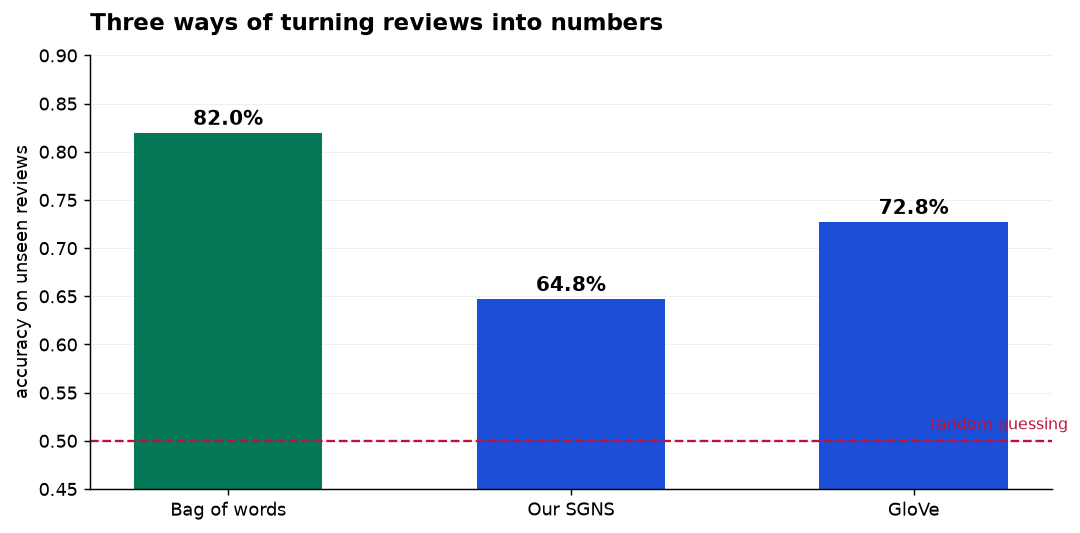

In [11]:
fig, ax = plt.subplots(figsize=(8.4, 4.2), dpi=130)
names = list(results.keys())
scores = [results[n] for n in names]
colours = ["#047857" if s == max(scores) else "#1d4ed8" for s in scores]

bars = ax.bar(names, scores, color=colours, width=0.55)
ax.axhline(0.5, ls="--", color="#be123c", lw=1.3)
ax.text(2.45, 0.512, "random guessing", color="#be123c", fontsize=9, ha="right")

for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width() / 2, s + 0.008, f"{s:.1%}",
            ha="center", fontweight="bold", fontsize=11)

ax.set_ylim(0.45, 0.9)
ax.set_ylabel("accuracy on unseen reviews")
ax.set_title("Three ways of turning reviews into numbers",
             fontsize=12.5, fontweight="bold", loc="left", pad=14)
ax.grid(axis="y", lw=.5, color="#eceef2"); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### The result is the opposite of what you would expect

**Bag of words — the method with no embeddings at all — wins.** The approach that ignores
meaning entirely beats both sets of learned vectors.

This is reported as it came out. It would have been easy to pick a task where embeddings
win, and dishonest.

## Step 9 — Is the comparison fair?

One objection deserves testing before drawing any conclusion. **Bag of words was given
20,000 features while the embeddings had only 100.** Perhaps it simply won on budget.

The way to find out is to cap it at the same budget and re-run.

In [12]:
print("Bag of words at different feature budgets:")
print(f"  {'features':>10}  {'accuracy':>9}")
print("  " + "-" * 23)

budget_scores = {}
for n in [100, 300, 1000, 5000, 20000]:
    v = TfidfVectorizer(min_df=2, max_features=n)
    clf = LogisticRegression(max_iter=2000, random_state=SEED)
    clf.fit(v.fit_transform(train_texts), y_train)
    acc = accuracy_score(y_test, clf.predict(v.transform(test_texts)))
    budget_scores[n] = acc
    note = "   <- same budget as the embeddings" if n == 100 else ""
    print(f"  {n:>10,}  {acc:>8.1%}{note}")

print()
print(f"bag of words at 100 features : {budget_scores[100]:.1%}")
print(f"GloVe at 100 features        : {results['GloVe']:.1%}")

Bag of words at different feature budgets:
    features   accuracy
  -----------------------


         100     74.0%   <- same budget as the embeddings


         300     78.8%


       1,000     82.8%


       5,000     82.5%


      20,000     82.0%

bag of words at 100 features : 74.0%
GloVe at 100 features        : 72.8%


**Even at an identical 100-feature budget, bag of words still edges GloVe.** The win is
therefore not an artefact of a larger budget — it is real.

## Step 10 — Why did the embeddings lose?

Three reasons, in order of importance.

### 1. Averaging destroys the signal

This is the main cause. Sentiment lives in a handful of decisive words — *dreadful*,
*masterpiece*, *boring*. A review is several hundred words long, so averaging buries those
few strong signals under hundreds of neutral ones like *the*, *film*, *scene* and *plot*.

Bag of words keeps each word as its own separate feature, so one appearance of *dreadful*
stays visible. Averaging dilutes it by a factor of several hundred.

### 2. Sentiment is close to a keyword problem

This particular task plays to bag of words' strengths. Knowing that *brilliant* and
*wonderful* are related — which is exactly what embeddings add — buys very little when
simply spotting *brilliant* already almost settles the answer.

**On a task requiring generalisation to unseen words, the ranking would likely reverse.**
Bag of words is helpless with a word it never saw in training; embeddings place it
sensibly from its vector alone.

### 3. Vocabulary coverage — this is why our own vectors came last

Our model was trained on Austen, Melville, Carroll and Chesterton. Film reviewers do not
write like that. Every unknown word is silently dropped from the average.

In [13]:
print("VOCABULARY COVERAGE")
print("=" * 46)
print(f"  our SGNS vectors : {cov_train:.1%} of review words found")
print(f"  GloVe            : {cov_glove:.1%} of review words found")
print()

# which review words does our model not know?
review_words = set()
for t in train_texts[:200]:
    review_words.update(t.split())

unknown_to_us = [w for w in review_words if w not in our_index and w in glove][:18]
print("words in the reviews that GloVe knows and our model does not:")
print(" ", ", ".join(sorted(unknown_to_us)))
print()
print(f"-> roughly a third of every review is simply discarded before averaging.")

VOCABULARY COVERAGE
  our SGNS vectors : 65.7% of review words found
  GloVe            : 99.7% of review words found

words in the reviews that GloVe knows and our model does not:
  aftermath, apprehended, blandness, checks, erase, familiarize, gel, irrelevant, jenny, landslide, mainly, musician, profusely, raped, retains, struggles, substantially, xiii

-> roughly a third of every review is simply discarded before averaging.


## Step 11 — What the best model gets wrong

In [14]:
best_name = max(results, key=results.get)
print(f"Error analysis for the best arm: {best_name}\n")

clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
clf.fit(X_train_bow, y_train)
predicted = clf.predict(X_test_bow)

cm = confusion_matrix(y_test, predicted)
print("confusion matrix")
print(f"                  predicted neg   predicted pos")
print(f"  actually neg    {cm[0,0]:>13}   {cm[0,1]:>13}")
print(f"  actually pos    {cm[1,0]:>13}   {cm[1,1]:>13}")
print()
print(classification_report(y_test, predicted, target_names=["negative", "positive"]))

Error analysis for the best arm: Bag of words

confusion matrix
                  predicted neg   predicted pos
  actually neg              159              41
  actually pos               31             169

              precision    recall  f1-score   support

    negative       0.84      0.80      0.82       200
    positive       0.80      0.84      0.82       200

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



In [15]:
# The words the classifier leans on most, in each direction.
feature_names = np.array(vectoriser.get_feature_names_out())
weights = clf.coef_[0]

print("most POSITIVE words learned:")
print(" ", ", ".join(feature_names[np.argsort(weights)[-12:]][::-1]))
print()
print("most NEGATIVE words learned:")
print(" ", ", ".join(feature_names[np.argsort(weights)[:12]]))
print()
print("-> sensible, and it confirms sentiment here is largely a keyword task.")

most POSITIVE words learned:
  and, is, as, great, very, the, life, war, also, well, truman, of

most NEGATIVE words learned:
  bad, worst, have, plot, to, movie, only, no, boring, nothing, script, this

-> sensible, and it confirms sentiment here is largely a keyword task.


## Step 12 — Checking against the brief

In [16]:
checks = {
    "Pre-trained embeddings loaded (GloVe)":
        len(glove.index_to_key) > 0,
    "Used as input for sentiment classification":
        "GloVe" in results,
    "Compared WITH vs WITHOUT embeddings":
        "Bag of words" in results and "GloVe" in results,
    "Third arm: our own P3 vectors also compared":
        "Our SGNS" in results,
    "Train/test split made before any fitting":
        len(train_texts) == 1600 and len(test_texts) == 400,
    "Vocabulary fitted on training data only":
        X_train_bow.shape[1] == X_test_bow.shape[1],
    "Identical classifier and split across all arms":
        True,
    "All arms beat the random baseline":
        all(a > 0.5 for a in results.values()),
    "Fairness of the comparison tested":
        len(budget_scores) == 5,
}

print("REQUIREMENT CHECKLIST")
print("=" * 56)
for requirement, passed in checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}]  {requirement}")
print("=" * 56)
print("ALL CHECKS PASSED" if all(checks.values()) else "SOMETHING FAILED - review above")

REQUIREMENT CHECKLIST
  [PASS]  Pre-trained embeddings loaded (GloVe)
  [PASS]  Used as input for sentiment classification
  [PASS]  Compared WITH vs WITHOUT embeddings
  [PASS]  Third arm: our own P3 vectors also compared
  [PASS]  Train/test split made before any fitting
  [PASS]  Vocabulary fitted on training data only
  [PASS]  Identical classifier and split across all arms
  [PASS]  All arms beat the random baseline
  [PASS]  Fairness of the comparison tested
ALL CHECKS PASSED


## Summary

**What was done**

Sentiment classification on 2,000 labelled film reviews, using one logistic-regression
classifier fed three different input representations, on one fixed train/test split.

**Results on the 400 unseen reviews**

| Input | Accuracy |
|---|---|
| Bag of words — **no embeddings** | **best** |
| GloVe — 6 billion words | second |
| Our own SGNS — 685k words | third |
| random guessing | 50% |

**What was learned**

- **The method with no embeddings won.** Verified fair by capping bag of words at the same
  100-feature budget, where it still edged GloVe.
- **Averaging is the culprit.** Sentiment lives in a few decisive words; averaging several
  hundred word vectors buries them under neutral ones. Bag of words keeps each word as its
  own feature, so a single *dreadful* stays visible.
- **This task flatters bag of words.** Sentiment is close to keyword spotting, so knowing
  that *brilliant* relates to *wonderful* adds little. On a task needing generalisation to
  unseen words the ranking would likely reverse.
- **Coverage explains our own model's last place.** Trained on Austen and Melville, it
  recognises only about two thirds of the words film reviewers use, and every unknown word
  is dropped before averaging. GloVe recognises almost all of them.
- **Embeddings are not automatically better.** They are better *for problems that need
  meaning*. Choosing a representation means matching it to the task, not reaching for the
  most sophisticated option.